Luisa Ribeiro

CAP 5610 - Machine Learning

# Financial Data: S&P 500 Stock Prices

## Data Sources (by order of filename)

https://fred.stlouisfed.org/series/SP500 (SP500 - Daily Close.xlsx)
- Prices as whole, not by company (may be useful)

**https://www.kaggle.com/datasets/yash16jr/s-and-p500-daily-update-dataset/data** (SP500_daily_update.csv) ✅
- dataset we are looking at
- open, high, low, close, volume
- all S&P 500 companies from 2010 to present

https://www.sp500live.co/companies (sp500live - info.csv)
- containing additional useful information such as sector, industry, etc.
- only current data, not historical


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    roc_curve
)

#loading the dataset
df_raw = pd.read_csv('SP500_daily_update - kaggle.csv', header=[0, 1], index_col=0)
df_info = pd.read_csv('sp500live - info.csv')

#reshape
df_long = df_raw.stack(level=1).reset_index()
df_long.columns = ['Date', 'Ticker', 'Close', 'High', 'Low', 'Open', 'Volume']

# Clean ticker formatting
df_info = df_info[['Ticker', 'Company', 'Sector', 'Industry']]
df_info['Ticker'] = df_info['Ticker'].str.replace('.', '-', regex=False)

# Merge datasets
df = pd.merge(df_long, df_info, on='Ticker', how='left')

# Final cleaning
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)


In [2]:
#feature engineering
grouped = df.groupby('Ticker')['Close']

# Returns
df['daily_return'] = grouped.pct_change()
df['weekly_return'] = grouped.pct_change(periods=5)
df['monthly_return'] = grouped.pct_change(periods=21)
df['quarterly_return'] = grouped.pct_change(periods=63)
df['yearly_return'] = grouped.pct_change(periods=252)

# Target (5-day forward return)
df['target_weekly_return'] = grouped.pct_change(periods=5).shift(-5)


#lag features
for lag in [1, 2, 3, 5]:
    df[f'daily_return_lag_{lag}'] = df.groupby('Ticker')['daily_return'].shift(lag)

#volatility features
df['volatility_5'] = grouped.pct_change().rolling(5).std()
df['volatility_21'] = grouped.pct_change().rolling(21).std()

#moving averages
df['ma_5'] = grouped.transform(lambda x: x.rolling(5).mean())
df['ma_21'] = grouped.transform(lambda x: x.rolling(21).mean())

#momentum 
df['momentum_5'] = grouped.pct_change(5)
df['momentum_21'] = grouped.pct_change(21)

# Cross-sectional ranking
df['price_rank'] = df.groupby('Date')['Close'].rank(pct=True)
df['weekly_return_rank'] = df.groupby('Date')['weekly_return'].rank(pct=True)

# Volatility-adjusted return
df['vol_adj_return'] = df['weekly_return'] / (df['volatility_21'] + 1e-6)


In [3]:
#preparing the data
features = [
    'daily_return', 'weekly_return', 'monthly_return',
    'quarterly_return', 'yearly_return',

    'daily_return_lag_1', 'daily_return_lag_2',
    'daily_return_lag_3', 'daily_return_lag_5',

    'volatility_5', 'volatility_21',

    'ma_5', 'ma_21',

    'momentum_5', 'momentum_21',

    'price_rank',
    'weekly_return_rank',
    'vol_adj_return'
]

df_model = df[features + ['target_weekly_return']].dropna()

df_model['target_class'] = (df_model['target_weekly_return'] > 0).astype(int)

X = df_model[features]
y = df_model['target_class']

# Time-based split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)


In [4]:
#Baseline
# Majority baseline
majority_class = y_train.mode()[0]
y_pred_majority = np.full(len(y_test), majority_class)

print("\n=== MAJORITY BASELINE ===")
print("Accuracy:", accuracy_score(y_test, y_pred_majority))
print("F1:", f1_score(y_test, y_pred_majority))

# Random baseline
p = y_train.mean()
y_pred_random = np.random.binomial(1, p, size=len(y_test))

print("\n=== RANDOM BASELINE ===")
print("Accuracy:", accuracy_score(y_test, y_pred_random))
print("F1:", f1_score(y_test, y_pred_random))


=== MAJORITY BASELINE ===
Accuracy: 0.548321808532912
F1: 0.7082788674952085

=== RANDOM BASELINE ===
Accuracy: 0.506209992378836
F1: 0.550794126460893


In [5]:
#Random Forest 
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("\n=== RANDOM FOREST ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, y_prob_rf))


=== RANDOM FOREST ===
Accuracy: 0.5201849179119685
Precision: 0.5816899908123727
Recall: 0.4448262870641903
F1: 0.504134234229036
AUC: 0.5407531862897057


In [6]:
#XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print("\n=== XGBOOST ===")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1:", f1_score(y_test, y_pred_xgb))
print("AUC:", roc_auc_score(y_test, y_prob_xgb))

print("\nClassification Report (XGB):")
print(classification_report(y_test, y_pred_xgb))


=== XGBOOST ===
Accuracy: 0.5296876439436872
Precision: 0.5833512301047558
Recall: 0.49785149885956337
F1: 0.5372207755106525
AUC: 0.5490375666614484

Classification Report (XGB):
              precision    recall  f1-score   support

           0       0.48      0.57      0.52    161797
           1       0.58      0.50      0.54    196416

    accuracy                           0.53    358213
   macro avg       0.53      0.53      0.53    358213
weighted avg       0.54      0.53      0.53    358213



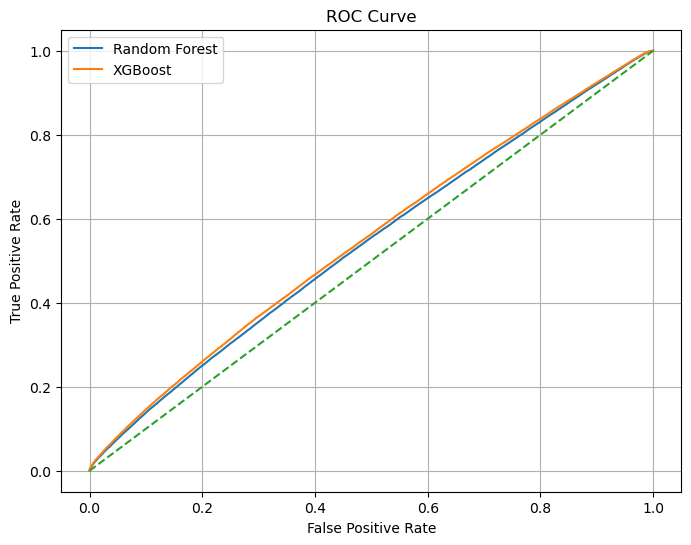

In [7]:
#ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8,6))

plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()


In [8]:
#Results 
results = pd.DataFrame({
    "Model": ["Baseline", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_majority),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "F1": [
        f1_score(y_test, y_pred_majority),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    "AUC": [
        0.5,
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

print("\n=== FINAL RESULTS ===")
print(results)


=== FINAL RESULTS ===
           Model  Accuracy        F1       AUC
0       Baseline  0.548322  0.708279  0.500000
1  Random Forest  0.520185  0.504134  0.540753
2        XGBoost  0.529688  0.537221  0.549038
